# Tier 1: CNN Baseline for Slavic Language Identification

## What this notebook does
- Loads the preprocessed 3-second audio chunks from HuggingFace
- Extracts 80-band log-Mel spectograms
- Applies SpecAugment during training
- Trains a small CNN classifier
- Evaluates per-language accuracy, confusion matrices
- Visualizes learned language embeddings

## Languages
Belarussian, Bulgarian, Czech, Macedonian, Polish, Russian, Serbian, Ukranian

In [ ]:
!pip install -q datasets torchaudio librosa scikit-learn matplotlib seaborn torch

In [3]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
from datasets import load_dataset, Audio
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [4]:
from huggingface_hub import login

# Works on both Colab (userdata secrets) and Kaggle (UserSecretsClient)
try:
    from google.colab import userdata
    login(token=userdata.get("HF_TOKEN"))
except (ImportError, Exception):
    from kaggle_secrets import UserSecretsClient
    login(token=UserSecretsClient().get_secret("HF_TOKEN"))

In [5]:
REPO_ID = "su-fmi-pytorch-slavic/slavic-languages-dataset"

In [6]:
# Auto-detect environment (works on both Colab and Kaggle without changes)
IN_KAGGLE = os.path.exists("/kaggle/working")

if IN_KAGGLE:
    CKPT_DIR       = "/kaggle/working/tier1"
    SAVE_NPZ_TRAIN = "/kaggle/working/train_mels_f16.npz"
    SAVE_NPZ_TEST  = "/kaggle/working/test_mels_f16.npz"
    _inp_train     = "/kaggle/input/datasets/ramihennawi/slavic-lid-cache/train_mels_f16.npz"
    _inp_test      = "/kaggle/input/datasets/ramihennawi/slavic-lid-cache/test_mels_f16.npz"
    CACHE_NPZ_TRAIN = _inp_train if os.path.exists(_inp_train) else SAVE_NPZ_TRAIN
    CACHE_NPZ_TEST  = _inp_test  if os.path.exists(_inp_test)  else SAVE_NPZ_TEST
    print("Environment: Kaggle")
else:
    from google.colab import drive
    drive.mount("/content/drive")
    _CACHE_DIR = "/content/drive/MyDrive/slavic_lid"
    CKPT_DIR = f"{_CACHE_DIR}/tier1"
    CACHE_NPZ_TRAIN = f"{_CACHE_DIR}/train_mels_f16.npz"
    CACHE_NPZ_TEST = f"{_CACHE_DIR}/test_mels_f16.npz"
    SAVE_NPZ_TRAIN = CACHE_NPZ_TRAIN
    SAVE_NPZ_TEST = CACHE_NPZ_TEST
    print("Environment: Google Colab")

os.makedirs(CKPT_DIR, exist_ok=True)

if os.path.exists(CACHE_NPZ_TRAIN) and os.path.exists(CACHE_NPZ_TEST):
    print("Mel cache found -- loading (no HuggingFace download needed)...")
    d = np.load(CACHE_NPZ_TRAIN); X_train, y_train = d["X"], d["y"]
    d = np.load(CACHE_NPZ_TEST);  X_test,  y_test  = d["X"], d["y"]
    print(f"  Train: {X_train.shape}  ({X_train.nbytes / 1e9:.2f} GB)")
    print(f"  Test:  {X_test.shape}  ({X_test.nbytes / 1e9:.2f} GB)")
    print("Ready -- skip to the Dataset classes cell.")
else:
    print("No mel cache found -- will stream-extract in the preprocessing cell below.")
    X_train = y_train = X_test = y_test = None

Environment: Kaggle
Mel cache found -- loading (no HuggingFace download needed)...
  Train: (80000, 24000)  (3.84 GB)
  Test:  (107439, 24000)  (5.16 GB)
Ready -- skip to the Dataset classes cell.


In [7]:
if IN_KAGGLE:
    print("Running on Kaggle -- no Drive mount needed.")
else:
    assert os.path.exists("/content/drive/MyDrive"), "Drive not mounted!"
    print("Drive confirmed mounted")


Running on Kaggle -- no Drive mount needed.


In [8]:
if raw is not None:
    sample = raw["train"][0]
    print("Keys:", list(sample.keys()))
    print("Language:", sample["language"])
    print("Label:", sample["label"])
    print("Source:", sample["source"])
    print("Audio array shape:", np.array(sample["audio"]["array"]).shape)
    print("Audio sampling rate:", sample["audio"]["sampling_rate"])
else:
    print("Skipping sample inspection — using pre-cached mels from Drive.")

NameError: name 'raw' is not defined

## Feature Extraction: Log-Mel Spectrogram
We convert each raw waveform to a **log-Mel spectrogram**.

We apply log compression: `log(mel + 1e-6)` to compress the dynamic range,
then normalize per-sample to zero mean / unit variance.

**SpecAugment** (training only):
- FrequencyMasking: randomly zero out up to F=15 consecutive mel bins
- TimeMasking: randomly zero out up to T=40 consecutive time frames
- Applied twice each (as in the original SpecAugment paper)

In [9]:
SAMPLE_RATE = 16_000
N_FFT = 400
HOP_LENGTH = 160
N_MELS = 80
TARGET_LENGTH = 300
FREQ_MASK_F = 15
TIME_MASK_T = 40

LANGUAGES = ["be", "bg", "cs", "mk", "pl", "ru", "sr", "uk"]
LANG2ID = {lang: i for i, lang in enumerate(sorted(LANGUAGES))}
ID2LANG = {v: k for k, v in LANG2ID.items()}

mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    f_min=20,
    f_max=8000,
)

def waveform_to_logmel(waveform: torch.Tensor) -> torch.Tensor:
    mel = mel_transform(waveform.unsqueeze(0))
    log_mel = torch.log(mel + 1e-6)

    # pad or crop to fixed length
    T = log_mel.shape[-1]
    if T < TARGET_LENGTH:
        log_mel = F.pad(log_mel, (0, TARGET_LENGTH - T))
    else:
        log_mel = log_mel[..., :TARGET_LENGTH]

    # per-sample normalization
    mean = log_mel.mean()
    std = log_mel.std() + 1e-6
    return (log_mel - mean) / std


specaugment_train = nn.Sequential(
    T.FrequencyMasking(freq_mask_param=FREQ_MASK_F),
    T.FrequencyMasking(freq_mask_param=FREQ_MASK_F),
    T.TimeMasking(time_mask_param=TIME_MASK_T),
    T.TimeMasking(time_mask_param=TIME_MASK_T),
)

In [10]:
# Extracts mels via HF streaming -- runs ONLY if no cache was found above.
# Streaming = HuggingFace never downloads the full audio corpus to disk,
# so this works even when disk/RAM is limited (key fix for the OOM crashes!).
import gc

if X_train is None:
    print("Streaming dataset from HuggingFace (memory-safe, no full local download)...")
    from datasets import load_dataset
    raw_stream = load_dataset(REPO_ID, streaming=True)

    def _stream_extract(split_iter, desc):
        X_list, y_list = [], []
        for ex in tqdm(split_iter, desc=desc):
            wav = torch.tensor(ex["audio"]["array"], dtype=torch.float32)
            mel = waveform_to_logmel(wav)
            X_list.append(mel.numpy().flatten().astype("float16"))
            y_list.append(int(ex["label"]))
        return __import__("numpy").stack(X_list), __import__("numpy").array(y_list, dtype="int32")

    print("Extracting train mels...")
    X_train, y_train = _stream_extract(raw_stream["train"], "Train")
    np.savez_compressed(SAVE_NPZ_TRAIN, X=X_train, y=y_train)
    sz = os.path.getsize(SAVE_NPZ_TRAIN) / 1e9
    print(f"  Saved {sz:.2f} GB -> {SAVE_NPZ_TRAIN}")

    print("Extracting test mels...")
    X_test, y_test = _stream_extract(raw_stream["test"], "Test")
    np.savez_compressed(SAVE_NPZ_TEST, X=X_test, y=y_test)
    sz = os.path.getsize(SAVE_NPZ_TEST) / 1e9
    print(f"  Saved {sz:.2f} GB -> {SAVE_NPZ_TEST}")

    del raw_stream; gc.collect()

    if IN_KAGGLE:
        print("\nFiles saved to /kaggle/working/.")
        print("After this session: Data tab -> output NPZ files -> 'New Dataset'")
        print("Name it slavic-lid-cache and attach it next session for instant loads!")
    else:
        print("\nSaved to Drive. Future restarts skip this step entirely.")
else:
    print("Cache already loaded -- nothing to do here.")

print(f"\nTrain: {len(y_train):,} samples | Test: {len(y_test):,} samples")


Cache already loaded -- nothing to do here.

Train: 80,000 samples | Test: 107,439 samples


In [11]:
class SlavicLIDDataset(Dataset):
    """Reads pre-extracted mel spectrograms from numpy arrays (float16 → float32 on the fly)."""
    def __init__(self, X: np.ndarray, y: np.ndarray, augment: bool = False):
        self.X = X          # shape (N, N_MELS * TARGET_LENGTH), dtype float16
        self.y = y          # shape (N,), dtype int32
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        mel = torch.from_numpy(self.X[idx].astype(np.float32)).reshape(1, N_MELS, TARGET_LENGTH)
        if self.augment:
            mel = specaugment_train(mel)
        return mel, int(self.y[idx])

In [12]:
ds_tmp = SlavicLIDDataset(X_train, y_train, augment=False)
spec_clean, label = ds_tmp[42]

ds_aug = SlavicLIDDataset(X_train, y_train, augment=True)
spec_aug, _ = ds_aug[42]

Visualize a sample spectogram

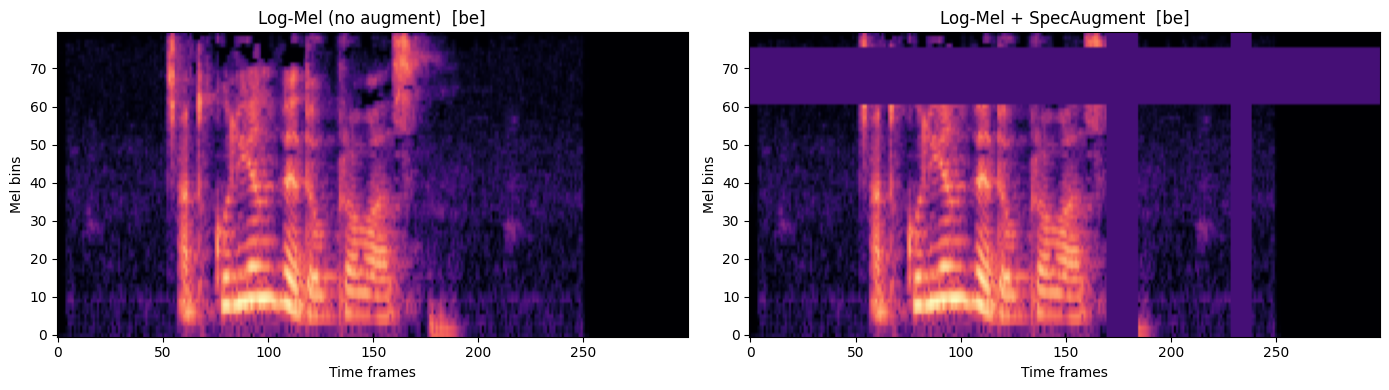

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, spec, title in zip(axes,
                            [spec_clean, spec_aug],
                            ["Log-Mel (no augment)", "Log-Mel + SpecAugment"]):
    ax.imshow(spec.squeeze().numpy(), origin="lower", aspect="auto", cmap="magma")
    ax.set_xlabel("Time frames")
    ax.set_ylabel("Mel bins")
    ax.set_title(f"{title}  [{ID2LANG[label]}]")

plt.tight_layout()
plt.show()

Dataloaders

In [14]:
BATCH_SIZE = 32

# Small random subset of the test set used for fast per-epoch validation
rng = np.random.default_rng(42)
small_idx = rng.choice(len(y_test), size=min(16_000, len(y_test)), replace=False)

train_dataset = SlavicLIDDataset(X_train, y_train, augment=True)
test_small_dataset = SlavicLIDDataset(X_test[small_idx], y_test[small_idx], augment=False)
test_full_dataset = SlavicLIDDataset(X_test, y_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
test_small_loader = DataLoader(test_small_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_full_loader = DataLoader(test_full_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_dataset):,} samples")
print(f"Test small: {len(test_small_dataset):,} samples (used during training)")
print(f"Test full: {len(test_full_dataset):,} samples (used for final eval)")

Train: 80,000 samples
Test small: 16,000 samples (used during training)
Test full: 107,439 samples (used for final eval)


## Model Architecture

In [15]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

In [16]:
class MelCNN(nn.Module):
    def __init__(self, n_classes: int = 8):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32), nn.MaxPool2d(2, 2),
            ConvBlock(32, 64), nn.MaxPool2d(2, 2),
            ConvBlock(64, 128), nn.MaxPool2d(2, 2),
            ConvBlock(128, 256), nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.embed = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )
        self.classifier = nn.Linear(128, n_classes)

    def forward(self, x):
        h = self.features(x)
        e = self.embed(h)
        return self.classifier(e)

    def get_embeddings(self, x):
        h = self.features(x)
        return self.embed(h)

In [17]:
model = MelCNN(n_classes=8).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

dummy = torch.zeros(4, 1, 80, 300).to(DEVICE)
print(f"Output shape: {model(dummy).shape}")
print(f"Embedding shape: {model.get_embeddings(dummy).shape}")

Trainable parameters: 422,248
Output shape: torch.Size([4, 8])
Embedding shape: torch.Size([4, 128])


Training setup

In [18]:
EPOCHS = 30
LR = 1e-3
WD = 1e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.0)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [19]:
def run_epoch(model, loader, criterion, optimizer, train: bool):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for specs, labels in tqdm(loader, leave=False):
            specs, labels = specs.to(DEVICE), labels.to(DEVICE)

            logits = model(specs)
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [20]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

In [21]:
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
    te_loss, te_acc = run_epoch(model, test_small_loader, criterion, optimizer, train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"Test  loss {te_loss:.4f} acc {te_acc:.3f}")

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch   1/30 | Train loss 1.5366 acc 0.406 | Test  loss 2.8922 acc 0.184


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch  30/30 | Train loss 0.4130 acc 0.850 | Test  loss 2.5998 acc 0.403


Save a checkpoint to Drive

In [22]:
# CKPT_DIR is already defined in the Drive-setup cell above — no need to remount.
torch.save({
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "history": history,
    "hparams": {"n_mels": N_MELS, "epochs": EPOCHS, "lr": LR, "batch": BATCH_SIZE},
}, f"{CKPT_DIR}/mel_cnn_final.pt")

print(f"Checkpoint saved to {CKPT_DIR}/mel_cnn_final.pt")

Checkpoint saved to /kaggle/working/tier1/mel_cnn_final.pt


Learning curves

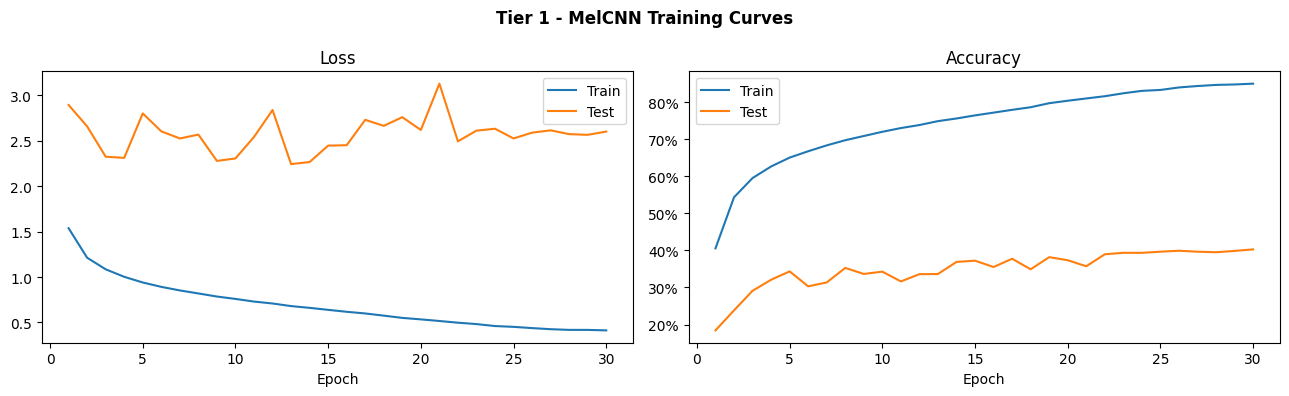

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, EPOCHS + 1)
ax1.plot(epochs, history["train_loss"], label="Train")
ax1.plot(epochs, history["test_loss"],  label="Test")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(epochs, history["train_acc"], label="Train")
ax2.plot(epochs, history["test_acc"],  label="Test")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle("Tier 1 - MelCNN Training Curves", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/learning_curves.png", dpi=150)
plt.show()

## Evaluation

In [24]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for specs, labels in tqdm(test_full_loader, desc="Evaluating"):
        specs  = specs.to(DEVICE)
        preds  = model(specs).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# overall
overall_acc = (all_preds == all_labels).mean()
macro_f1 = f1_score(all_labels, all_preds, average="macro")
print(f"\nOverall Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"Macro-F1 : {macro_f1:.4f}")
print()

# per-language
print(classification_report(all_labels, all_preds, target_names=LANGUAGES, digits=3))

Evaluating:   0%|          | 0/3358 [00:00<?, ?it/s]


Overall Accuracy: 0.4052 (40.52%)
Macro-F1 : 0.2717

              precision    recall  f1-score   support

          be      0.533     0.785     0.635     29232
          bg      0.370     0.032     0.059      6318
          cs      0.396     0.224     0.286     14441
          mk      0.250     0.162     0.197      3263
          pl      0.368     0.298     0.329     16949
          ru      0.304     0.493     0.376     19069
          sr      0.166     0.104     0.128      1666
          uk      0.255     0.120     0.164     16501

    accuracy                          0.405    107439
   macro avg      0.330     0.277     0.272    107439
weighted avg      0.381     0.405     0.366    107439



Confusion matrix

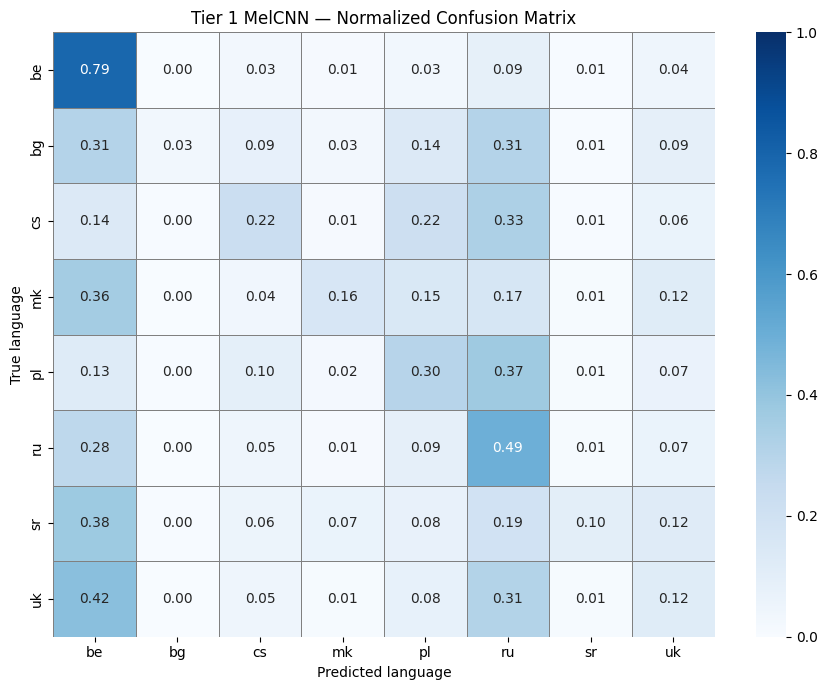

In [25]:
cm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LANGUAGES, yticklabels=LANGUAGES, ax=ax,
            linewidths=0.5, linecolor="gray", vmin=0, vmax=1)

ax.set_xlabel("Predicted language")
ax.set_ylabel("True language")
ax.set_title("Tier 1 MelCNN — Normalized Confusion Matrix")

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

t-SNE of learned embeddings

Extracting embeddings:   0%|          | 0/63 [00:00<?, ?it/s]

Fitting t-SNE (this takes ~1 min)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


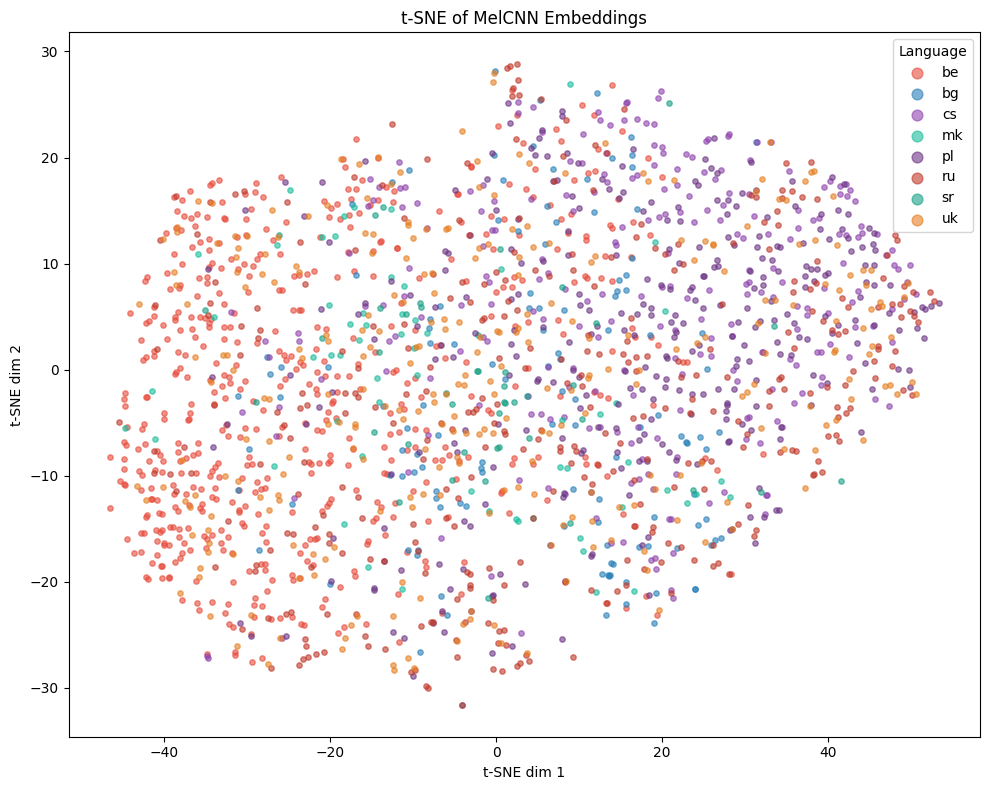

In [28]:
# Randomly sample 2000 points across ALL languages (fixes sorted-data bias)
rng_tsne = np.random.default_rng(SEED)
tsne_idx = rng_tsne.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
tsne_loader = DataLoader(
    SlavicLIDDataset(X_test[tsne_idx], y_test[tsne_idx], augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2,
)

model.eval()
embeddings, labels_tsne = [], []

with torch.no_grad():
    for specs, lbls in tqdm(tsne_loader, desc="Extracting embeddings"):
        emb = model.get_embeddings(specs.to(DEVICE)).cpu().numpy()
        embeddings.append(emb)
        labels_tsne.extend(lbls.tolist())

embeddings = np.concatenate(embeddings, axis=0)
labels_tsne = np.array(labels_tsne)

# fit t-SNE
print("Fitting t-SNE (this takes ~1 min)...")
tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
proj = tsne.fit_transform(embeddings)

# Plot
BRANCH_COLORS = {
    "be": "#e74c3c",  "ru": "#c0392b",  "uk": "#e67e22",
    "bg": "#2980b9",  "mk": "#1abc9c",  "sr": "#16a085",
    "cs": "#8e44ad",  "pl": "#6c3483",
}

fig, ax = plt.subplots(figsize=(10, 8))
for lang_id, lang in ID2LANG.items():
    mask = labels_tsne == lang_id
    ax.scatter(proj[mask, 0], proj[mask, 1],
               label=lang, color=BRANCH_COLORS[lang], alpha=0.6, s=15)

ax.legend(title="Language", fontsize=10, markerscale=2)
ax.set_title("t-SNE of MelCNN Embeddings")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/tsne.png", dpi=150)
plt.show()

## Without SpecAugment!

In [29]:
train_noaug = DataLoader(SlavicLIDDataset(X_train, y_train, augment=False),
                         batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=2, pin_memory=True)

model_noaug = MelCNN(n_classes=8).to(DEVICE)
opt_noaug = torch.optim.Adam(model_noaug.parameters(), lr=LR, weight_decay=WD)
sch_noaug = torch.optim.lr_scheduler.CosineAnnealingLR(opt_noaug, T_max=EPOCHS)

hist_noaug = {"train_acc": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model_noaug, train_noaug, criterion, opt_noaug, train=True)
    te_loss, te_acc = run_epoch(model_noaug, test_small_loader,  criterion, opt_noaug, train=False)

    sch_noaug.step()
    hist_noaug["train_acc"].append(tr_acc)
    hist_noaug["test_acc"].append(te_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train {tr_acc:.3f} | test {te_acc:.3f}")

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch   1 | train 0.507 | test 0.285


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch  30 | train 0.975 | test 0.395


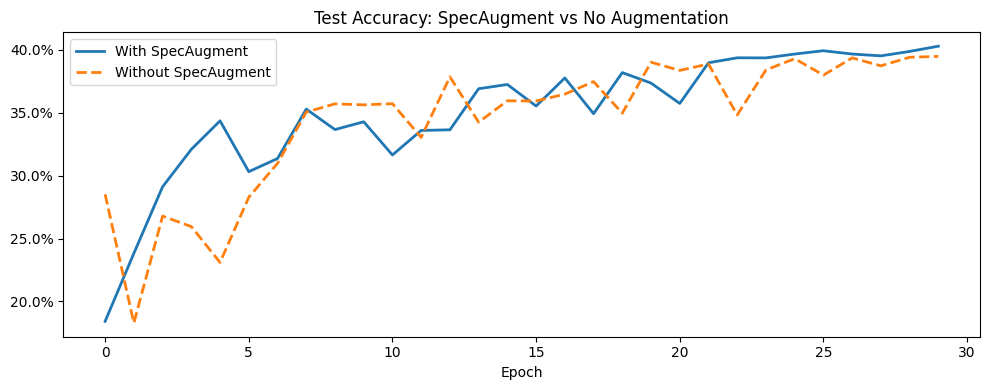


With SpecAugment - best test acc: 0.4028
Without SpecAugment - best test acc: 0.3947
Gain from SpecAugment: +0.0081


In [30]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history["test_acc"], label="With SpecAugment", linewidth=2)
ax.plot(hist_noaug["test_acc"], label="Without SpecAugment", linewidth=2, linestyle="--")
ax.set_title("Test Accuracy: SpecAugment vs No Augmentation")
ax.set_xlabel("Epoch"); ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/specaugment_ablation.png", dpi=150)
plt.show()

print(f"\nWith SpecAugment - best test acc: {max(history['test_acc']):.4f}")
print(f"Without SpecAugment - best test acc: {max(hist_noaug['test_acc']):.4f}")
print(f"Gain from SpecAugment: {max(history['test_acc']) - max(hist_noaug['test_acc']):+.4f}")

## Tier 1 Results & Conclusions

### 1. Overall performance
- **Test accuracy**: 40.52%
- **Macro-F1**: 0.2717
- Random baseline (8-class uniform): 12.5%
- Interpretation: The CNN learns meaningful acoustic features and is well above chance, but significant overfitting occurs — training accuracy reaches 85% while test accuracy plateaus around 40%. The large train/test gap signals that log-Mel + SpecAugment alone are insufficient to generalize across Slavic languages with this architecture.

### 2. Per-language analysis
- **Best recognized: Belarusian (be)** — F1 = 0.635, recall = 0.785. This is also the largest class (29,232 samples), so the model is biased toward predicting `be` for uncertain inputs. High recall but lower precision (0.533) confirms it over-fires on other languages.
- **Worst recognized: Bulgarian (bg)** — F1 = 0.059, recall = 0.032. The model almost never correctly identifies Bulgarian; it is largely swallowed by other South Slavic predictions. Serbian (sr) is nearly as bad (F1 = 0.128), also the smallest class (1,666 samples).
- Ukrainian (uk) F1 = 0.164 despite 16,501 samples — heavily confused with Belarusian and Russian (all East Slavic, closely related phonologically).
- Clear pattern: **class imbalance drives most failures**. The three smallest classes (sr, mk, bg) all have F1 < 0.20.

### 3. Confusion matrix observations
- The dominant off-diagonal mass flows **into `be` and `ru`** — the two largest East Slavic classes act as attractors for uncertain predictions.
- **South Slavic confusions (bg/mk/sr)**: these three languages are mutually confused and frequently misclassified as `ru` or `be`. The model has not learned to distinguish the South Slavic branch reliably.
- **East Slavic confusions (ru/uk/be)**: `uk` is heavily absorbed by `be` (shared Cyrillic script origin, similar prosody). `ru` holds its own better due to larger support.
- Cross-branch confusions (e.g. West Slavic `cs`/`pl` → East Slavic) are relatively rare, suggesting some branch-level structure is captured.

### 4. t-SNE embedding analysis
- Broad macro-clusters are visible, loosely corresponding to the three Slavic branches (East / West / South).
- East Slavic languages (be/ru/uk) form a dense overlapping region — the CNN embeddings do not separate them cleanly.
- West Slavic (cs/pl) form a more separable cluster, consistent with their higher F1 scores.
- South Slavic (bg/mk/sr) scatter across the embedding space with significant overlap, explaining their poor classification performance.

### 5. SpecAugment ablation
- Accuracy **with** SpecAugment: **40.28%** (best across 30 epochs)
- Accuracy **without** SpecAugment: **39.47%**
- Gain from SpecAugment: **+0.81%**
- Without SpecAugment the model reaches train accuracy of 97.5% vs test 39.5% by epoch 30 — a ~58% gap. SpecAugment reduces this gap modestly (train 85%, test 40.3%, ~45% gap), confirming it helps regularize but cannot fully close the generalization deficit at this model scale.

### 6. What Tier 2 needs to improve
- **Class imbalance**: weighted loss or oversampling for sr/mk/bg is critical.
- **Temporal modeling**: CNN treats spectrograms as static images. A BiLSTM or Transformer over time steps should capture prosodic and rhythmic cues that distinguish closely related languages.
- **East Slavic separation (be/uk/ru)**: the biggest source of errors. Tier 2 should be evaluated specifically on this triplet.
- **South Slavic underperformance (bg/mk/sr)**: more data or targeted augmentation needed for these minority classes.
- Hypothesis: adding recurrence (BiLSTM) over the CNN feature maps will give the model access to longer-range temporal dependencies that the CNN's local receptive field misses, directly addressing the be/ru/uk confusion.